# 01 — Opportunity inventory and action links (v2)

Builds the v2 Chile finance release: the harmonised opportunity inventory and the action links, gated by current-use evidence.

The organising rule is that how specifically a fund matches an action follows from how specific the fund is. A targeted route can support a specific match, a general route can only support a general one, and a route that buys readiness can never support a capital claim. Most of the match type therefore derives from the route profile rather than being assigned by hand; the only judgement stored is whether a targeted fund covers the whole of an action or a part of it.

Contract and vocabulary: `../../methodology.md` → *Action-to-opportunity matching*. Release contract: `review.md`.

## Parameters

In [1]:
import json
from pathlib import Path

import pandas as pd

RELEASE_VERSION = "v2"
MAPPING_SOURCE = "oef-route-derived-v2"

HERE = Path.cwd()
REPO_ROOT = HERE.parents[5]

COMPILE_PATH = REPO_ROOT / "dataset-compile/cl-climate-finance-opportunities/data.csv"
ACTIONS_PATH = REPO_ROOT / "dataset-review/reviews/climateview/climateview-transition-elements/releases/2026-02-23/data/current_actions.csv"
DELIVERY_PATH = HERE / "data/action_delivery_mode.csv"
CROSSWALK_PATH = HERE / "data/action_opportunity_mapping.csv"
V1_INVENTORY_PATH = HERE.parent / "v1/data/chile_finance_inventory.csv"
DATA_OUT = HERE / "data"

pd.set_option("display.max_colwidth", 55)
pd.Series(
    {name: path.exists() for name, path in [
        ("compile", COMPILE_PATH), ("actions", ACTIONS_PATH), ("delivery modes", DELIVERY_PATH),
        ("crosswalk", CROSSWALK_PATH), ("v1 inventory", V1_INVENTORY_PATH)]},
    name="inputs_resolved",
).to_frame()

,inputs_resolved
compile,True
actions,True
delivery modes,True
crosswalk,True
v1 inventory,True


## 1. Load raw

Five inputs, read with no transformation. The compile supplies both the opportunity records and their route profile: how targeted the route is, what the money buys, and whether a municipality can receive it. The delivery-mode file says what each action takes to deliver. The crosswalk holds the only hand-assigned judgement in the release. None of the inputs carries personal data.

In [2]:
compile_raw = pd.read_csv(COMPILE_PATH, dtype=str).fillna("")
actions_raw = pd.read_csv(ACTIONS_PATH, dtype=str).fillna("")
delivery = pd.read_csv(DELIVERY_PATH, dtype=str).fillna("")
crosswalk = pd.read_csv(CROSSWALK_PATH, dtype=str).fillna("")
v1_inventory = pd.read_csv(V1_INVENTORY_PATH, dtype=str).fillna("")

pd.DataFrame(
    [("compile opportunities", len(compile_raw)), ("climate actions", len(actions_raw)),
     ("action delivery modes", len(delivery)), ("crosswalk judgements", len(crosswalk)),
     ("v1 inventory rows", len(v1_inventory))],
    columns=["input", "rows"],
)

,input,rows
0,compile opportunities,100
1,climate actions,102
2,action delivery modes,102
3,crosswalk judgements,21
4,v1 inventory rows,99


## 2. Opportunity identifier

Every opportunity is addressed by a deterministic slug of its source dataset and programme name, so the crosswalk, the inventory and any downstream loader agree on one key without a hand-maintained lookup.

In [3]:
import re
import unicodedata


def opportunity_id(program_name: str, source_dataset: str) -> str:
    ascii_name = unicodedata.normalize("NFKD", program_name).encode("ascii", "ignore").decode()
    slug = re.sub(r"[^a-z0-9]+", "-", ascii_name.lower())
    return f"{source_dataset}-{re.sub(r'-+', '-', slug).strip('-')}"


opportunities = compile_raw.assign(
    source_opportunity_id=[
        opportunity_id(name, dataset)
        for name, dataset in zip(compile_raw["program_name"], compile_raw["source_dataset"])
    ]
)
opportunities[["source_opportunity_id", "route_scope", "funds_what", "municipality_eligible"]].head()

,source_opportunity_id,route_scope,funds_what,municipality_eligible
0,cl-mma-fpa-2026-proyectos-sustentables-ciudadanos,targeted,asset,no
1,cl-mma-fpa-2026-proyectos-sustentables-en-estableci...,targeted,asset,no
2,cl-mma-fpa-2026-proyectos-sustentables-para-pueblos...,targeted,asset,no
3,cl-mma-fpa-extraordinario-rapa-nui-2026,targeted,asset,no
4,cl-mma-fpa-2025-alto-del-carmen-ecosistemas-altoand...,targeted,asset,no


## 3. Harmonise the inventory

The inventory keeps the v1 column structure so an existing consumer reads v2 unchanged. The compile's status vocabulary is wider than the inventory's, so a rolling programme becomes ongoing and a revoked one becomes closed; where the compile never reverified a record, the seed's own status claim is kept rather than inventing one. Verification notes are appended only for records the compile actually checked.

In [4]:
STATUS_TO_INVENTORY = {"rolling": "ongoing", "revoked": "closed", "unknown": ""}
INVENTORY_FIELDS = list(v1_inventory.columns)


def inventory_status(row: pd.Series) -> str:
    if not row["normalized_status"]:
        return row["status_claim"]
    return STATUS_TO_INVENTORY.get(row["normalized_status"], row["normalized_status"])


def inventory_notes(row: pd.Series) -> str:
    if row["verification_status"] == "seed_not_reverified" or not row["verification_notes"]:
        return row["notes_claim"]
    return f"{row['notes_claim']} Verification: {row['verification_notes']}".strip()


inventory_full = opportunities.assign(
    status=opportunities.apply(inventory_status, axis=1),
    notes=opportunities.apply(inventory_notes, axis=1),
    status_as_of=opportunities["verified_as_of"].where(
        opportunities["verified_as_of"] != "", opportunities["status_as_of_claim"]
    ),
)
inventory = inventory_full[INVENTORY_FIELDS]
inventory.head()

,source_dataset,funder_institution,program_name,program_family,eligible_actor,instrument_type,amount_clp,amount_note,open_date,close_date,...,recurrence,specificity,climate_relevance,climate_relevance_norm,gpc_sectors,access_pathway,detail_level,status_as_of,source_url,notes
0,cl-mma,Ministerio del Medio Ambiente (MMA),FPA 2026 - Proyectos Sustentables Ciudadanos,FPA Ciudadanos,community/citizen org,grant,6000000.0,,2025-08-26,2025-10-07,...,annual,sector-specific,explicit,explicit,"[""cross_sector"", ""waste"", ""stationary_energy"", ""afo...",direct application (via fondos.gob.cl),detailed,2026-06-08,https://fondos.mma.gob.cl/fpa-2026-proyectos-susten...,FPA
1,cl-mma,Ministerio del Medio Ambiente (MMA),FPA 2026 - Proyectos Sustentables en Establecimient...,FPA Educacionales,community/citizen org,grant,6000000.0,,2025-08-26,2025-10-07,...,annual,sector-specific,explicit,explicit,"[""cross_sector"", ""waste"", ""stationary_energy"", ""afo...",direct application (via fondos.gob.cl),detailed,2026-06-08,https://fondos.mma.gob.cl/fpa-2026-proyectos-susten...,FPA
2,cl-mma,Ministerio del Medio Ambiente (MMA),FPA 2026 - Proyectos Sustentables para Pueblos Indí...,FPA Pueblos Indígenas,indigenous community,grant,6000000.0,,2025-08-26,2025-10-07,...,annual,sector-specific,explicit,explicit,"[""cross_sector"", ""waste"", ""stationary_energy"", ""afo...",direct application (via fondos.gob.cl),detailed,2026-06-08,https://fondos.mma.gob.cl/fpa-2026-proyectos-susten...,FPA
3,cl-mma,Ministerio del Medio Ambiente (MMA),FPA Extraordinario Rapa Nui 2026,FPA Rapa Nui,indigenous community,grant,100000000.0,amount_suspect (source typo),2025-10-02,2025-10-24,...,sporadic,sector-specific,explicit,explicit,"[""afolu""]",direct application (via fondos.gob.cl),detailed,2026-06-08,https://fondos.mma.gob.cl/fpa-2026-rapanui/,FPA
4,cl-mma,Ministerio del Medio Ambiente (MMA),FPA 2025 - Alto del Carmen: Ecosistemas Altoandinos...,FPA Alto del Carmen,research/university + ngo,grant,70000000.0,,2025-08-05,2025-09-17,...,one-off,sector-specific,explicit,explicit,"[""afolu""]",direct application (via fondos.gob.cl),detailed,2026-06-08,https://fondos.mma.gob.cl/altodelcarmen-hidrico-2025/,FPA


## 4. What each kind of money can pay for

One table drives the whole derivation: for each thing a fund buys, which kinds of action it can pay for. Credit reaches nothing here, because a loan or guarantee is a way to finance a project rather than a route to a particular action, and treating it as coverage would overstate what a city can reach.

In [5]:
REACHES = {
    "asset":       {"city_works"},
    "equipment":   {"city_equipment"},
    "practice":    {"third_party_practice"},
    "preparation": {"city_plan", "city_programme"},
    "credit":      set(),
    "unknown":     set(),
}
SECTORS = ["stationary_energy", "transportation", "waste", "afolu", "industry"]
# city_rule is a valid delivery mode that no fund reaches: a standard or ban needs
# authority, not capital. Its absence from REACHES is the point, not an omission.
DELIVERY_MODES = {"city_works", "city_equipment", "city_rule", "city_plan", "city_programme", "third_party_practice"}

pd.DataFrame(
    [(buys, ", ".join(sorted(modes)) or "nothing") for buys, modes in REACHES.items()],
    columns=["the money buys", "so it can pay for an action delivered as"],
)

,the money buys,so it can pay for an action delivered as
0,asset,city_works
1,equipment,city_equipment
2,practice,third_party_practice
3,preparation,"city_plan, city_programme"
4,credit,nothing
5,unknown,nothing


## 5. Derive the general routes

A general fund reaches an action when a municipality can receive the money, the fund buys what the action takes to deliver, and the action's sector is one the fund covers. Nothing here is a judgement about the pair. A fund still tagged `cross_sector` is read as covering every sector, which is deliberately permissive: resolving those tags is open compile work, and `funds_what` is doing the real constraining in the meantime.

In [6]:
mode_by_action = dict(zip(delivery["action_id"], delivery["delivery_mode"]))
sector_by_action = dict(zip(delivery["action_id"], delivery["sector"]))


def covered_sectors(themes_norm: str) -> set:
    themes = json.loads(themes_norm) if themes_norm else []
    return set(SECTORS) if "cross_sector" in themes else {t for t in themes if t in SECTORS}


general_rows, suppressed_rows = [], []
for fund in opportunities.itertuples():
    sectors, reaches = covered_sectors(fund.themes_norm), REACHES[fund.funds_what]
    for action in delivery.itertuples():
        if action.sector not in sectors or action.delivery_mode not in reaches:
            continue
        record = {
            "source_opportunity_id": fund.source_opportunity_id, "opportunity_name": fund.program_name,
            "action_id": action.action_id, "reason": fund.municipality_eligible,
        }
        if fund.municipality_eligible == "yes" and fund.route_scope == "general":
            general_rows.append(record)
        elif fund.municipality_eligible != "yes":
            suppressed_rows.append(record)

general = pd.DataFrame(general_rows)
suppressed = pd.DataFrame(suppressed_rows)

pd.Series(
    {"general routes derived": len(general),
     "suppressed, route not open to a municipality": int((suppressed["reason"].isin(["no", "implementer"])).sum()),
     "withheld, city eligibility unknown": int((suppressed["reason"] == "unknown").sum())},
    name="derivation",
).to_frame()

,derivation
general routes derived,180
"suppressed, route not open to a municipality",562
"withheld, city eligibility unknown",508


## 6. Assemble the link table

The five match types come together here. A targeted fund that buys preparation always yields `prepares`, whatever the crosswalk says about it, because a planning grant cannot buy an asset. Such a row keeps `match_basis: reviewed`, because a person still decided which actions that fund prepares; what the rule forces is the type, not the pair. A targeted fund that buys anything else takes the crosswalk's `whole` or `part`. Everything derived in the previous block is `general_route`.

Coverage then needs both halves. A reviewed link can name a fund that finances an action while a municipality has no way to receive that money, which is true and worth keeping: it is the actor gap, and deleting it would hide funding that exists in the territory. Such a link keeps its match type and is marked as not city-applicable, so it never counts as coverage for the city.

In [7]:
COVERAGE = {"whole", "part"}
TYPE_ORDER = {"whole": 0, "part": 1, "prepares": 2, "general_route": 3}

fund_by_id = opportunities.set_index("source_opportunity_id")
judged = crosswalk[crosswalk["covers"] != "none"].copy()

rows = []
for row in judged.itertuples():
    fund = fund_by_id.loc[row.source_opportunity_id]
    match_type = "prepares" if fund.funds_what == "preparation" else row.covers
    rows.append({
        "source_opportunity_id": row.source_opportunity_id, "action_id": row.action_id,
        "match_type": match_type, "match_basis": "reviewed", "mapping_confidence": row.mapping_confidence,
        "rationale": row.rationale, "validation_needed": row.validation_needed,
    })
for row in general.itertuples():
    fund = fund_by_id.loc[row.source_opportunity_id]
    rows.append({
        "source_opportunity_id": row.source_opportunity_id, "action_id": row.action_id,
        "match_type": "general_route", "match_basis": "rule", "mapping_confidence": "",
        "rationale": f"General municipal route: the fund buys {fund.funds_what} and a municipality can receive it.",
        "validation_needed": "Confirm the specific project against the programme's current operating rules.",
    })

links = pd.DataFrame(rows)
links = links.assign(
    opportunity_name=links["source_opportunity_id"].map(fund_by_id["program_name"]),
    source_dataset=links["source_opportunity_id"].map(fund_by_id["source_dataset"]),
    route_scope=links["source_opportunity_id"].map(fund_by_id["route_scope"]),
    funds_what=links["source_opportunity_id"].map(fund_by_id["funds_what"]),
    opportunity_status=links["source_opportunity_id"].map(inventory_full.set_index("source_opportunity_id")["status"]),
    action_name=links["action_id"].map(dict(zip(delivery["action_id"], delivery["action_name"]))),
    sector=links["action_id"].map(sector_by_action),
    delivery_mode=links["action_id"].map(mode_by_action),
    city_can_apply=links["source_opportunity_id"].map(fund_by_id["municipality_eligible"]),
    current_display_eligible=links["source_opportunity_id"].map(fund_by_id["current_display_eligible"]).str.lower(),
    mapping_source=MAPPING_SOURCE,
)
links["counts_as_coverage"] = [
    str(match in COVERAGE and city == "yes").lower()
    for match, city in zip(links["match_type"], links["city_can_apply"])
]
links["recommended_display"] = [
    "show" if eligible == "true" and covers == "true" else "hide"
    for eligible, covers in zip(links["current_display_eligible"], links["counts_as_coverage"])
]
links = (
    links.assign(_o=links["match_type"].map(TYPE_ORDER))
    .sort_values(["action_id", "_o", "opportunity_name"]).drop(columns="_o").reset_index(drop=True)
)

pd.crosstab(links["match_type"], links["city_can_apply"]).reindex(list(TYPE_ORDER)).fillna(0).astype(int)

city_can_apply,no,yes
match_type,,
whole,1,4
part,3,8
prepares,0,4
general_route,0,180


## 7. Action-level coverage

Coverage and route are counted separately and never summed. An action is covered when a targeted fund a municipality can apply to finances the whole of it or a material part. An action with only general or preparation links has a route to explore, not coverage. An action is territory-only when the money for it exists in Chile but goes to someone other than the city, which is the actor gap made visible: those funds emit no links, so without this state they would be indistinguishable from actions nobody funds at all. Only an action with none of the three is a genuine gap. The distinction is the entire point of the release, so it is carried in two columns rather than one score.

In [8]:
by_action = {action_id: group for action_id, group in links.groupby("action_id")}
territory_routes = suppressed.groupby("action_id").size().to_dict()
summary_rows = []
for action in delivery.itertuples():
    group = by_action.get(action.action_id)
    types = group["match_type"].value_counts().to_dict() if group is not None else {}
    covered = int(group["counts_as_coverage"].eq("true").sum()) if group is not None else 0
    reviewed_non_city = int(((group["counts_as_coverage"] == "false") & (group["match_basis"] == "reviewed")).sum()) if group is not None else 0
    territory = territory_routes.get(action.action_id, 0) + reviewed_non_city
    if covered:
        state = "covered"
    elif types.get("general_route", 0) or types.get("prepares", 0):
        state = "route_only"
    elif territory:
        state = "territory_only"
    else:
        state = "none"
    summary_rows.append({
        "action_id": action.action_id, "action_name": action.action_name, "sector": action.sector,
        "delivery_mode": action.delivery_mode, "coverage_state": state,
        "n_whole": types.get("whole", 0), "n_part": types.get("part", 0),
        "n_prepares": types.get("prepares", 0), "n_general_route": types.get("general_route", 0),
        "n_covered": covered, "n_territory_only_routes": territory,
        "n_currently_displayable": int((group["recommended_display"] == "show").sum()) if group is not None else 0,
    })
summary = pd.DataFrame(summary_rows)

pd.crosstab(summary["sector"], summary["coverage_state"]).reindex(columns=["covered", "route_only", "territory_only", "none"]).fillna(0).astype(int)

coverage_state,covered,route_only,territory_only,none
sector,,,,
afolu,5,4,15,2
industry,0,0,21,7
stationary_energy,1,10,9,10
transportation,1,1,3,3
waste,4,3,0,3


## 8. Validate

Nothing is exported unless every assertion holds. Beyond the usual retention and integrity checks, three of these guard the design itself: that a preparation fund never produces a coverage claim, that a general route never does either, and that no link exists for a fund a municipality cannot receive.

In [9]:
# Lossless retention: v1 records all survive, with exactly one addition.
assert len(v1_inventory) == 99 and len(inventory) == 100, (len(v1_inventory), len(inventory))
v1_names, v2_names = set(v1_inventory["program_name"]), set(inventory["program_name"])
assert v1_names <= v2_names and len(v2_names - v1_names) == 1

# The two hand-maintained inputs are complete and attributed.
assert set(delivery["action_id"]) == set(actions_raw["action_id"]) and len(delivery) == 102
assert set(delivery["delivery_mode"]) <= DELIVERY_MODES
assert delivery[["adjudicated_by", "adjudicated_on"]].ne("").all().all()
assert set(crosswalk["covers"]) <= {"whole", "part", "none", ""}
assert set(crosswalk["mapping_confidence"]) <= {"high", "medium", "low", "none", ""}
assert (crosswalk.loc[crosswalk["covers"] == "none", "mapping_confidence"] == "none").all()
assert crosswalk["rationale"].str.len().gt(0).all()
assert set(crosswalk["source_opportunity_id"]) <= set(opportunities["source_opportunity_id"])
assert not crosswalk[crosswalk["covers"] != "none"].duplicated(["source_opportunity_id", "action_id"]).any()
# A blank covers value is only meaningful for a fund that buys preparation.
for row in crosswalk[crosswalk["covers"] == ""].itertuples():
    assert fund_by_id.loc[row.source_opportunity_id, "funds_what"] == "preparation", row.opportunity_name

# Referential integrity and uniqueness of the emitted links.
assert set(links["action_id"]) <= set(delivery["action_id"])
assert set(links["source_opportunity_id"]) <= set(opportunities["source_opportunity_id"])
assert not links.duplicated(["source_opportunity_id", "action_id"]).any()
assert set(links["match_type"]) <= set(TYPE_ORDER)
assert set(links["match_basis"]) == {"reviewed", "rule"}

# The design rules, asserted rather than trusted.
assert (links.loc[links["funds_what"] == "preparation", "match_type"] == "prepares").all(), "a preparation fund produced a coverage claim"
assert (links.loc[links["route_scope"] == "general", "match_type"] == "general_route").all(), "a general route produced a specific match"
# Only a route known to be targeted may carry a specific match; unknown scope is not a licence.
assert (links.loc[links["match_type"].isin(COVERAGE), "route_scope"] == "targeted").all(), "a route of unknown scope produced a coverage claim"
assert (links.loc[links["match_type"] == "general_route", "route_scope"] == "general").all()
derived = links[links["match_basis"] == "rule"]
assert derived["city_can_apply"].eq("yes").all(), "a route no municipality can receive was derived as a general route"
assert (links.loc[links["city_can_apply"] != "yes", "counts_as_coverage"] == "false").all(), "a route the city cannot apply to counted as coverage"
assert (links["counts_as_coverage"] == [str(m in COVERAGE and c == "yes").lower() for m, c in zip(links["match_type"], links["city_can_apply"])]).all()
for row in links.itertuples():
    assert mode_by_action[row.action_id] in REACHES[row.funds_what] or row.match_basis == "reviewed"

# Availability stays a separate gate, and the compile currently withholds every record.
assert (opportunities["current_display_eligible"].str.lower() == "false").all()
assert (links["recommended_display"] == "hide").all()

# The known Chile false positive stays gone.
assert links[(links["action_id"] == "icare_0121") & (links["opportunity_name"].str.startswith("Renueva tu Colectivo"))].empty

# Action coverage is complete and internally consistent.
assert len(summary) == 102
assert summary["n_covered"].sum() == int(links["counts_as_coverage"].eq("true").sum())
assert summary["n_currently_displayable"].sum() == 0

pd.Series(
    {"opportunities": len(inventory), "hand judgements": len(crosswalk), "links emitted": len(links),
     "of which reviewed": int(links["match_basis"].eq("reviewed").sum()),
     "of which derived": int(links["match_basis"].eq("rule").sum()),
     "actions": len(summary), "assertions": "all passed"},
    name="validation",
).to_frame()

,validation
opportunities,100
hand judgements,21
links emitted,200
of which reviewed,20
of which derived,180
actions,102
assertions,all passed


## 9. Export

Two pipeline-ready tables leave this notebook. The delivery modes and the crosswalk are committed inputs rather than outputs, and the action summary stays in the notebook because it is an aggregate of the links.

In [10]:
LINK_FIELDS = [
    "source_opportunity_id", "opportunity_name", "source_dataset", "action_id", "action_name", "sector",
    "delivery_mode", "route_scope", "funds_what", "match_type", "match_basis", "city_can_apply", "mapping_confidence",
    "rationale", "validation_needed", "counts_as_coverage", "opportunity_status",
    "current_display_eligible", "recommended_display", "mapping_source",
]

DATA_OUT.mkdir(parents=True, exist_ok=True)
inventory.to_csv(DATA_OUT / "chile_finance_inventory.csv", index=False)
links[LINK_FIELDS].to_csv(DATA_OUT / "finance_opportunity_action.csv", index=False)

pd.DataFrame([(p.name, p.stat().st_size) for p in sorted(DATA_OUT.glob("*.csv"))], columns=["file", "bytes"])

,file,bytes
0,action_delivery_mode.csv,23190
1,action_opportunity_mapping.csv,7270
2,chile_finance_inventory.csv,59065
3,finance_opportunity_action.csv,91126


## 10. What the release looks like

Three questions: how much of the catalogue is covered rather than merely routed, what the actions with nothing actually are, and how concentrated the reviewed coverage is. Charts render inline; the precise figures are tables in `review.md`.

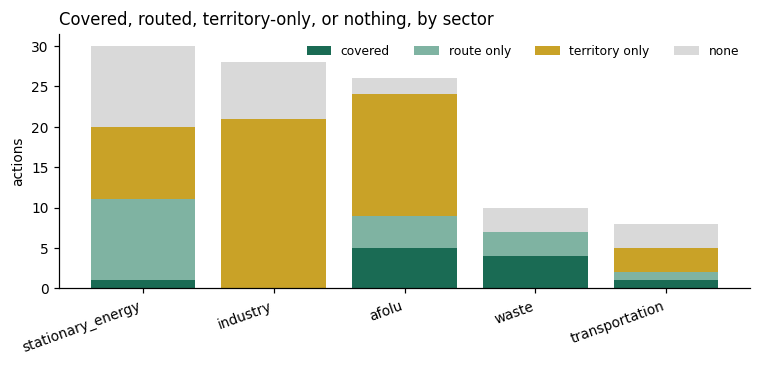

In [11]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})

view = pd.crosstab(summary["sector"], summary["coverage_state"]).reindex(columns=["covered", "route_only", "territory_only", "none"]).fillna(0).astype(int)
view = view.loc[view.sum(axis=1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(7, 3.4))
bottom = [0] * len(view)
for column, colour in zip(["covered", "route_only", "territory_only", "none"], ["#1a6b54", "#7fb3a2", "#c9a227", "#d9d9d9"]):
    ax.bar(view.index, view[column], bottom=bottom, color=colour, label=column.replace("_", " "))
    bottom = [b + v for b, v in zip(bottom, view[column])]
ax.set_ylabel("actions")
ax.set_title("Covered, routed, territory-only, or nothing, by sector", loc="left")
ax.legend(frameon=False, ncol=4, fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

Coverage is thin everywhere and absent in industry. The middle band is where a general municipal fund exists but no one has checked whether a specific project would qualify.

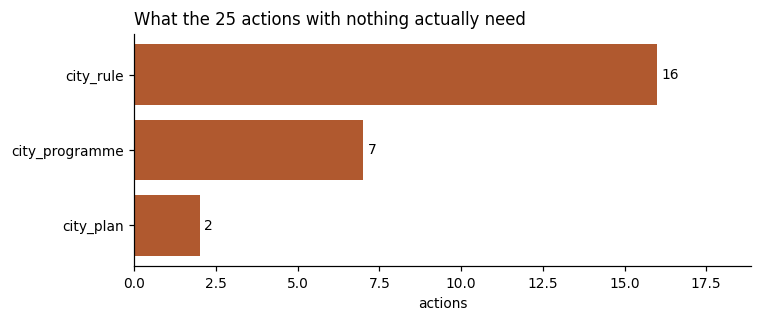

,actions
delivery_mode,
city_rule,16
city_programme,7
city_plan,2


In [12]:
gap = summary[summary["coverage_state"] == "none"]["delivery_mode"].value_counts()
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(gap.index[::-1], gap.values[::-1], color="#b0592f")
ax.bar_label(bars, padding=3)
ax.set_xlabel("actions")
ax.set_title(f"What the {len(summary[summary['coverage_state'] == 'none'])} actions with nothing actually need", loc="left")
ax.set_xlim(0, gap.max() * 1.18)
plt.tight_layout()
plt.show()

gap.to_frame("actions")

This is the chart that reframes the gap. Most of it is not missing money: it is actions that need authority rather than capital, and actions whose asset belongs to a firm, a farmer or a utility.

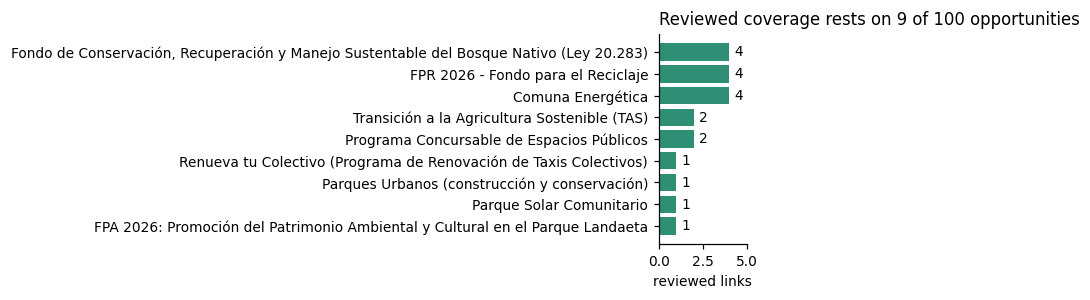

In [13]:
reviewed = links[links["match_basis"] == "reviewed"]
per_fund = reviewed.groupby("opportunity_name").size().sort_values()
fig, ax = plt.subplots(figsize=(7, 2.8))
bars = ax.barh(per_fund.index, per_fund.values, color="#2f8f74")
ax.bar_label(bars, padding=3)
ax.set_xlabel("reviewed links")
ax.set_title(f"Reviewed coverage rests on {len(per_fund)} of {len(inventory)} opportunities", loc="left")
ax.set_xlim(0, per_fund.max() * 1.25)
plt.tight_layout()
plt.show()

## 11. Findings

The derivation carries most of the load. Of the links emitted, the great majority are computed from the route profile and the action's delivery mode; the hand-maintained crosswalk is twenty-one rows. That is the intended shape, and it means coverage grows by reverifying funds in the compile rather than by adjudicating pairs.

Three facts flowed back into the release documents.

Separating what a fund buys from how targeted it is resolved the category that never made sense. Every conditional link in the previous draft was a general municipal fund being forced to express a non-pair-level fact as a pair; those now derive as general routes and the category is gone. The same split retired the complementary label, which described a fund that does not finance the action and therefore had nothing to record.

The gap is not mostly a funding gap. Of the actions with no link at all, the large majority need authority rather than capital, or belong to a firm, farmer or utility that the city cannot buy for. The residue that genuinely needs municipal capital and has no route is small and specific, and it is worth reading as a real finding rather than a data gap.

The action catalogue carries source-side text defects that pass through untouched: at least one action name holds a spelling error and several carry trailing spaces. Joins must use the action id.

Adjudication record: the 102 delivery modes and the 21 crosswalk judgements were adjudicated by amanda@openearth.org on 2026-08-16. The delivery mode is a property of the action catalogue rather than of this dataset and should move upstream to the ClimateView review when that entry next changes.